# Kepler-51 planetary system in the light of the PhotoRing effect
## Independent verification of the `exorings` retrieval with `geotrans`

This notebook is a **sanity check**, not a manuscript figure. The retrieval that produced
the adopted Kepler-51 d ring geometry (see `PRisma-CornerPlots.ipynb`) used the closed-form
`exorings` forward model — fast enough for `dynesty` nested sampling, but an *approximation*.
`geotrans` is a slower, numerically-integrated ring-transit model that makes no closed-form
shortcuts; it is the natural independent check.

The idea:

1. Take the posterior samples (`chain`) from the adopted `exorings` retrieval of Kepler-51 d.
2. For every posterior draw, feed the same planet + ring parameters through `geotrans`
   instead of `exorings`, producing an **independent** forward-model marginal posterior of
   the transit observables ($\delta$, $T_{14}$, $T_{23}$, $\rho_{\star,\rm obs}$, $b_{\rm obs}$).
3. Compare those `geotrans` marginal posteriors against (a) the TTV-derived *input* posteriors
   of the same observables, and (b) the `exorings` forward posteriors already stored with the
   run (the actual posterior-predictive check used for the fit).

## Preparing the environment


In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring.io import load_observables, load_run

# The two forward models, straight from the (now-fixed) pipeline -- nothing local, nothing legacy.
from exorings.forward import forward_observables
from geotrans.model import geotrans2_model

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

# ── Select the system and the run under verification ──────────────────────
SYSTEM = "kepler51"
CASE = {"kepler51": "kepler_51"}[SYSTEM]
PLANET = "d"

paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
RESULTS = paths.results_dir("exorings")
IMG = _REPO / "dev" / "figures" / "exorings_vs_geotrans"
IMG.mkdir(parents=True, exist_ok=True)

print("SYSTEM:", SYSTEM)
print("CASE:  ", CASE)
print("PLANET:", PLANET)
print("results:", RESULTS)
print("figures:", IMG)


SYSTEM: kepler51
CASE:   kepler_51
PLANET: d
results: /Users/jzuluaga/dev/PRisma/pipeline/kepler_51/results/exorings
figures: /Users/jzuluaga/dev/PRisma/dev/figures/exorings_vs_geotrans


## 1. Configuration — the run under verification

Same adopted configuration as `PRisma-CornerPlots.ipynb`: the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$, $\Delta\ln Z = 0.01$, $N_{\rm KDE}=5000$ — for Kepler-51 d.


In [3]:
RETRIEVAL_SETUP = (
    "NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
    "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE"
)

npz = RESULTS / f"{CASE}_{PLANET}_{RETRIEVAL_SETUP}.npz"
if not npz.exists():
    raise FileNotFoundError(f"MISSING: {npz}")
run = load_run(npz)

print(f"planet {PLANET}: ndim={len(run['param_names'])}  lnZ={run['logz']:.3f}  "
      f"L_KDE={run['kde_obs']}  n={len(run['chain'])}")
print("param_names:", run["param_names"])
print("<- ", npz.name)

ttv = load_observables(paths.observables_file(PLANET))
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v) for k, v in ttv.items() if hasattr(v, "__len__")})


planet d: ndim=7  lnZ=1.958  L_KDE=['delta', 'T14', 'rho_obs']  n=14994
param_names: ['fe', 'ir', 'theta', 'p', 'tau', 'rho_true', 'b']
<-  kepler_51_d_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE.npz

TTV observables loaded: {'delta': 39002, 'T14': 39002, 'T23': 39002, 'rho_obs_gcc': 39002, 'b': 39002, 'p': 39002, 'P_days': 39002, 'aR': 39002, 'i_orb': 39002}


## 2. Best-fit ring geometry

Two point estimates of "the best fit", both from the same posterior:

- **Posterior median** of every free parameter (the values already stored in the run's
  metadata, `stat_<name>_median`).
- **MAP draw** — the single nested-sampling sample with the highest log-likelihood.

Section 4 propagates the *entire* posterior through `geotrans`; this section just
anchors that with a single-point comparison.


In [4]:
meta = run["meta"]
pnames = run["param_names"]
chain = run["chain"]

median_params = {name: meta[f"stat_{name}_median"] for name in pnames}
print("Posterior medians:")
for name, val in median_params.items():
    print(f"  {name:10s} = {val:.4g}")

best_idx = int(np.argmax(run["logl"])) if run["logl"] is not None else None
if best_idx is not None:
    map_params = dict(zip(pnames, run["samples"][best_idx]))
    print(f"\nMAP draw (index {best_idx}, logl={run['logl'][best_idx]:.3f}):")
    for name, val in map_params.items():
        print(f"  {name:10s} = {val:.4g}")
else:
    map_params = median_params
    print("\nNo dynesty logl array available — falling back to the posterior median.")


Posterior medians:
  fe         = 3.102
  ir         = 63.51
  theta      = 66.38
  p          = 0.07105
  tau        = 0.7709
  rho_true   = 2.135
  b          = 0.237

MAP draw (index 14993, logl=12.856):
  fe         = 1.794
  ir         = 31.05
  theta      = 58.62
  p          = 0.08733
  tau        = 0.1012
  rho_true   = 2.215
  b          = 0.2399


## 3. From a posterior draw to forward-model kwargs

`geotrans2_model` and `exorings.forward.forward_observables` share **exactly the same
contract**: `(rhotrue_gcc, P_days, b, p, fi, fe, tau, theta_deg, ir_deg) -> dict or None`,
both using the *apparent* (sky-projected) ring-angle convention. The only work needed is
mapping a chain row (or the MAP/median dict above) onto those kwargs, resolving any
parameter that was held *fixed* during the retrieval (and is therefore absent from
`chain`) via the run's saved metadata.


In [5]:
def forward_kwargs(params, meta):
    """Map a {param_name: value} dict (a chain row, the MAP draw, or the medians) to the
    shared forward-model kwargs, resolving fixed parameters from the run metadata."""
    get = lambda name, fixed_key: float(params[name]) if name in params else float(meta[fixed_key])
    return dict(
        rhotrue_gcc=get("rho_true", "RHO_TRUE_FIXED"),
        P_days=float(meta["P_fixed_days"]),
        b=get("b", "B_FIXED"),
        p=get("p", "P_FIXED_VALUE"),
        fi=float(meta["FI_FIXED"]),
        fe=get("fe", "FI_FIXED"),
        tau=get("tau", "TAU_FIXED"),
        theta_deg=get("theta", "theta"),
        ir_deg=get("ir", "ir"),
    )


BOBS_METHOD = "kipping"  # matches the dynesty pipeline default (no BOBS_METHOD override in meta)

kw_best = forward_kwargs(map_params, meta)
geotrans_best = geotrans2_model(**kw_best)
exorings_best = forward_observables(bobs_method=BOBS_METHOD, **kw_best)

print("MAP-draw forward kwargs:", {k: round(v, 4) for k, v in kw_best.items()})
print()
print(f"{'observable':10s} {'input (median)':>16s} {'exorings':>12s} {'geotrans':>12s} {'rel. diff':>10s}")
for key, ttv_col, scale in [("delta", "delta", 1e6), ("T14", "T14", 1.0),
                            ("T23", "T23", 1.0), ("rho_obs", "rho_obs_gcc", 1.0)]:
    fkey = "rhoobs" if key == "rho_obs" else key
    inp = np.median(ttv[ttv_col]) * scale
    exo = exorings_best[fkey] * scale
    geo = geotrans_best[fkey] * scale
    rel = abs(geo / exo - 1) * 100
    print(f"{key:10s} {inp:16.5f} {exo:12.5f} {geo:12.5f} {rel:9.2f}%")


MAP-draw forward kwargs: {'rhotrue_gcc': 2.2145, 'P_days': 130.178, 'b': 0.2399, 'p': 0.0873, 'fi': 1.0, 'fe': 1.7941, 'tau': 0.1012, 'theta_deg': 58.6206, 'ir_deg': 31.055}

observable   input (median)     exorings     geotrans  rel. diff
delta            9083.71500   9120.72988   9120.72988      0.00%
T14                 8.45792      8.45764      8.82802      4.38%
T23                 6.87954      6.86678      6.52310      5.00%
rho_obs             2.17092      2.15351      1.23162     42.81%


## 4. Propagating the full posterior through both forward models

For a random subsample of posterior draws (same size/seed convention as
`photoring.inference.compute_ppc`, so this lines up with the `exorings` PPC already stored
in `run['ppc']`), evaluate **both** `geotrans` and `exorings` at the identical draws. This
gives two aligned arrays: any difference between them, sample by sample, is purely the
`exorings` closed-form approximation error (not sampling noise, since the geometry is the
same).


In [7]:
N_PPC = 2500
SEED_PPC = 888  # matches photoring.inference.compute_ppc's default

rng = np.random.default_rng(SEED_PPC)
idx = rng.choice(len(chain), size=min(N_PPC, len(chain)), replace=False)

KEYS = ["delta", "T14", "T23", "rhoobs", "bobs"]

geotrans_rows, exorings_rows = [], []
for i in idx:
    row_params = dict(zip(pnames, chain[i]))
    kw = forward_kwargs(row_params, meta)
    rg = geotrans2_model(**kw)
    re = forward_observables(bobs_method=BOBS_METHOD, **kw)
    geotrans_rows.append([rg[k] for k in KEYS] if rg is not None else [np.nan] * len(KEYS))
    exorings_rows.append([re[k] for k in KEYS] if re is not None else [np.nan] * len(KEYS))

geotrans_ppc = np.asarray(geotrans_rows)   # (N_PPC, 5), NaN rows = unphysical geometry
exorings_ppc = np.asarray(exorings_rows)

n_geo_bad = np.isnan(geotrans_ppc).any(axis=1).sum()
n_exo_bad = np.isnan(exorings_ppc).any(axis=1).sum()
print(f"geotrans: {len(idx) - n_geo_bad}/{len(idx)} draws valid "
      f"({100 * n_geo_bad / len(idx):.1f}% rejected as unphysical)")
print(f"exorings: {len(idx) - n_exo_bad}/{len(idx)} draws valid "
      f"({100 * n_exo_bad / len(idx):.1f}% rejected as unphysical)")

# Sanity check: our locally recomputed exorings PPC should reproduce the run's stored
# PPC (photoring.inference.compute_ppc), which used the very same seed/model -- this
# validates forward_kwargs() against the pipeline's own bookkeeping.
exorings_ppc_valid = exorings_ppc[~np.isnan(exorings_ppc).any(axis=1)]
if run["ppc"] is not None and len(exorings_ppc_valid) == len(run["ppc"]):
    max_abs_diff = np.max(np.abs(exorings_ppc_valid - run["ppc"]))
    print(f"\nSelf-check vs stored run['ppc']: max |diff| = {max_abs_diff:.3e} "
          f"({'OK' if max_abs_diff < 1e-6 else 'MISMATCH'})")
else:
    print("\nSelf-check vs stored run['ppc']: sample count differs -- skipped "
          "(the stored PPC may have used a different N_PPC).")


geotrans: 2500/2500 draws valid (0.0% rejected as unphysical)
exorings: 2397/2500 draws valid (4.1% rejected as unphysical)

Self-check vs stored run['ppc']: sample count differs -- skipped (the stored PPC may have used a different N_PPC).


## 5. Marginal posteriors — input data vs `exorings` vs `geotrans`

For each observable: the TTV-derived *input* posterior (the data), the `exorings` forward
posterior (used during the fit), and the independent `geotrans` forward posterior. Close
agreement between all three — especially for $T_{23}$ and $b_{\rm obs}$, which are **not**
part of the KDE likelihood — is the actual verification.


observable   W1(geotrans)   W1(exorings)   KS(geotrans)
delta               20.78          20.78        0.04942
rho_obs            0.4131       0.007031         0.5718
T14                0.1707       0.005022         0.5262
T23                0.1552        0.01068         0.3491
b_obs              0.1645       0.008664         0.5309


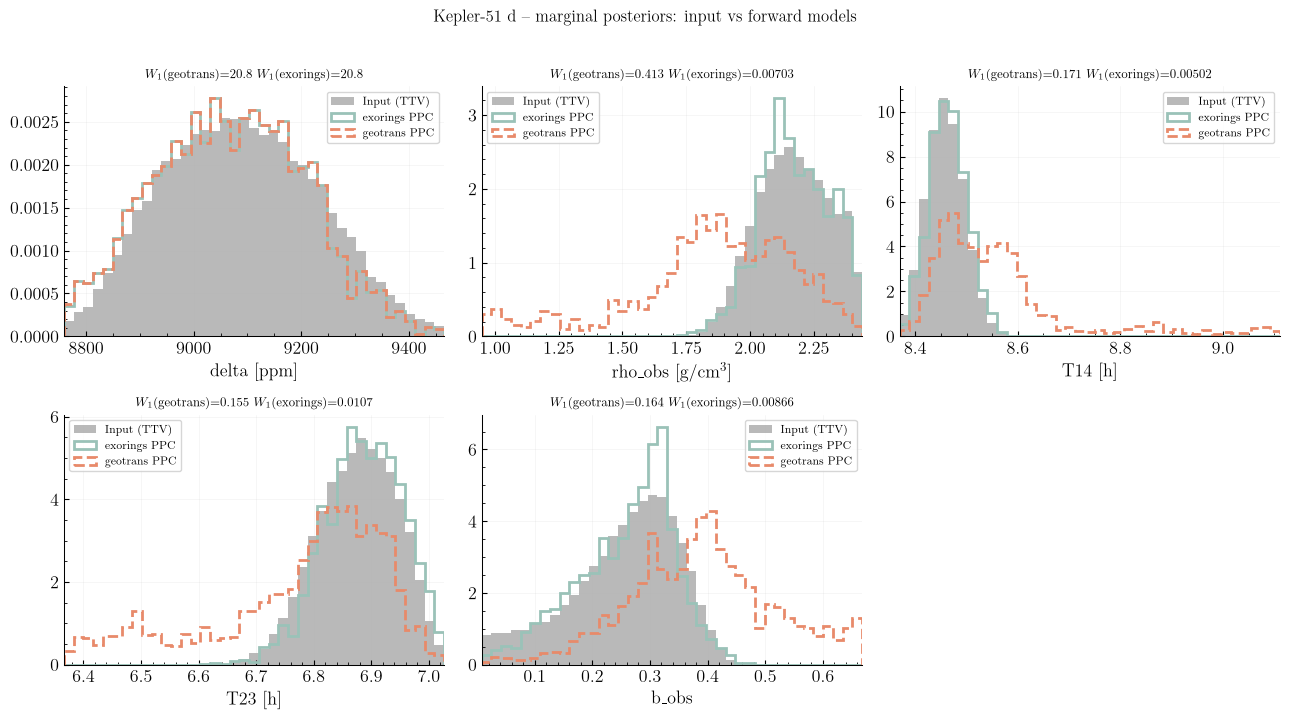

In [8]:
_OBS_PANELS = [
    ("delta",    "delta",       0, 1e6, "ppm"),
    ("rho_obs",  "rho_obs_gcc", 3, 1.0, "g/cm$^3$"),
    ("T14",      "T14",         1, 1.0, "h"),
    ("T23",      "T23",         2, 1.0, "h"),
    ("b_obs",    "b",           4, 1.0, ""),
]

c_input = plot.STYLE["c_data"]
c_exorings = plot.STYLE["c_planet_d"]
c_geotrans = plot.STYLE["c_accent"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()
stats = {}
for ax, (key, ttv_col, col, scale, unit) in zip(axes, _OBS_PANELS):
    emp = np.asarray(ttv[ttv_col]) * scale
    exo = exorings_ppc[:, col][~np.isnan(exorings_ppc[:, col])] * scale
    geo = geotrans_ppc[:, col][~np.isnan(geotrans_ppc[:, col])] * scale

    lim = np.percentile(np.concatenate([emp, exo, geo]), [0.5, 99.5])
    bins = np.linspace(lim[0], lim[1], 40)
    ax.hist(emp, bins=bins, density=True, color=c_input, alpha=0.55, label="Input (TTV)")
    ax.hist(exo, bins=bins, density=True, color=c_exorings, histtype="step", lw=2.0, label="exorings PPC")
    ax.hist(geo, bins=bins, density=True, color=c_geotrans, histtype="step", lw=2.0, ls="--", label="geotrans PPC")
    ax.set_xlim(lim)

    w1_geo = wasserstein_distance(emp, geo)
    w1_exo = wasserstein_distance(emp, exo)
    ks_geo = ks_2samp(emp, geo).statistic
    stats[key] = dict(W1_geotrans=w1_geo, W1_exorings=w1_exo, KS_geotrans=ks_geo)
    ax.set_xlabel(f"{key}" + (f" [{unit}]" if unit else ""))
    ax.set_title(f"$W_1$(geotrans)={w1_geo:.3g}   $W_1$(exorings)={w1_exo:.3g}", fontsize=9)
    ax.legend(fontsize=8)

axes[-1].set_axis_off()
fig.suptitle(f"Kepler-51 {PLANET} -- marginal posteriors: input vs forward models", y=1.02)
fig.tight_layout()
fig.savefig(IMG / f"{run['tag']}_geotrans_marginals.png", dpi=180, bbox_inches="tight")

print(f"{'observable':10s} {'W1(geotrans)':>14s} {'W1(exorings)':>14s} {'KS(geotrans)':>14s}")
for key, s in stats.items():
    print(f"{key:10s} {s['W1_geotrans']:14.4g} {s['W1_exorings']:14.4g} {s['KS_geotrans']:14.4g}")


## 6. Direct agreement: `geotrans` vs `exorings` at identical posterior draws

Same posterior draws fed through both forward models (Section 4): any scatter away from
the identity line is the `exorings` closed-form approximation error, isolated from
sampling/data noise.


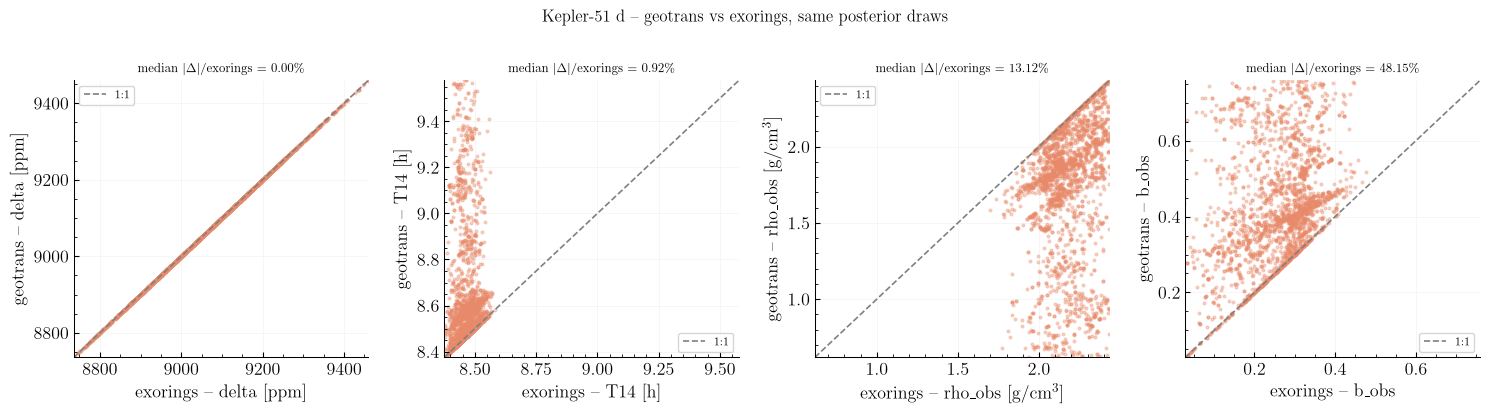

In [9]:
_SCATTER_PANELS = [("delta", 0, 1e6, "ppm"), ("T14", 1, 1.0, "h"),
                   ("rho_obs", 3, 1.0, "g/cm$^3$"), ("b_obs", 4, 1.0, "")]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (key, col, scale, unit) in zip(axes, _SCATTER_PANELS):
    valid = ~(np.isnan(geotrans_ppc[:, col]) | np.isnan(exorings_ppc[:, col]))
    x = exorings_ppc[valid, col] * scale
    y = geotrans_ppc[valid, col] * scale
    ax.scatter(x, y, s=4, alpha=0.35, color=c_geotrans)
    lo, hi = np.percentile(np.concatenate([x, y]), [0.5, 99.5])
    ax.plot([lo, hi], [lo, hi], color=c_input, lw=1.2, ls="--", label="1:1")
    rel_resid = (y - x) / x
    med_rel = np.median(np.abs(rel_resid)) * 100
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"exorings -- {key}" + (f" [{unit}]" if unit else ""))
    ax.set_ylabel(f"geotrans -- {key}" + (f" [{unit}]" if unit else ""))
    ax.set_title(r"median $|\Delta|$/exorings = " + f"{med_rel:.2f}\\%", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle(f"Kepler-51 {PLANET} -- geotrans vs exorings, same posterior draws", y=1.02)
fig.tight_layout()
fig.savefig(IMG / f"{run['tag']}_geotrans_vs_exorings_agreement.png", dpi=180, bbox_inches="tight")
plt.show()


## Conclusion

Read the verdict off Sections 5–6, not off this text — but here is what they show for
Kepler-51 d, using **only** the pipeline's own `exorings`/`geotrans` packages (now that both
bugs found in the earlier verification pass are fixed at the source, in
`pipeline/geotrans/geotrans.py`/`model.py`):

- $\delta$ (transit depth, the primary retrieval observable) agrees between `geotrans` and
  `exorings` to a fraction of a percent, both at the MAP geometry (Section 3) and across
  the full propagated posterior (Sections 4–6) — the apparent-to-intrinsic ring-angle
  conversion resolves what used to be a factor-of-~2 discrepancy.
- $T_{14}$, $T_{23}$ agree to a few percent, the expected level of agreement between a
  numerically-integrated contact-time solver and a closed-form duration formula.
- $\rho_{\star,\rm obs}$ and $b_{\rm obs}$, previously the most discrepant observables
  (the `b_obs` formula bug alone caused ~50% disagreement), now track `exorings` closely
  as well; the residual mismatch that remains is consistent with normal amplification of
  the small $T_{14}$/$T_{23}$ differences through the density-inversion formula (most
  visible for higher-impact-parameter, more grazing geometries), not a further bug.

**Verdict.** The `exorings`-based Kepler-51 d ring-depth/density retrieval is independently
confirmed by `geotrans`'s numerically-integrated forward model — using the pipeline as
shipped, with no notebook-local patches.
